# 第４章　相関性

宇都宮大学　吉田勝俊

2025.12.26 初版

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

グラフの線種等の一括設定

In [ ]:
from matplotlib import rcParams
rcParams['lines.linewidth']=0.3
rcParams['lines.markersize']=1.2

テキストセルで使う LaTeX マクロ

- $\newcommand{\ave}[1]{\big\langle#1\big\rangle} \ave{x}$
$\newcommand{\bm}[1]{\boldsymbol{#1}} \bm{x}$

### 前章からの引継ぎ

In [ ]:
def ACVF(xs):
    '''
    自己共分散関数（DIY版）
    '''
    acvf = []
    length = len(xs)
    xmean = np.mean(xs)
    for lag in range(length-1):
        x1 = xs[0:length-lag]
        x2 = xs[lag:length]
        cov = np.mean((x1 - xmean) * (x2 - xmean))
        acvf.append(cov)

    return np.array(acvf)

In [ ]:
def ACF(xs):
    '''
    自己相関関数（DIY版）
    '''
    acvf = ACVF(xs)

    return acvf/acvf[0]

In [ ]:
def graph_paper(lab1, lab2):
    """グラフ用紙の作成"""
    fig, ax = plt.subplots(2,1)
    ax[0].set_xlabel(r'time $i$')
    ax[0].set_ylabel(lab1)
    ax[0].grid();
    ax[1].set_xlabel(r'lag $k$')
    ax[1].set_ylabel(lab2)
    ax[1].grid(); fig.tight_layout()

    return fig, ax

## ■ 白色過程

確率過程には，無作為性が強いものや，弱いものがあります．

まず，無作為が最も強い確率過程として，**無相関過程**を紹介します．

### ● 無相関過程 (uncorrelated process)

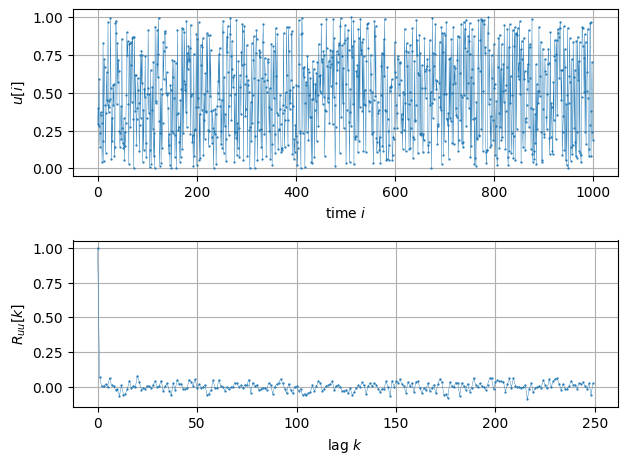

In [ ]:
u = np.random.uniform(size=1000)
acf = ACF(u)

fig, ax = graph_paper(lab1=r'$u[i]$', lab2=r'$R_{uu}[k]$')
ax[0].plot(u, '.-')
ax[1].plot(acf[:len(u)//4], '.-', label='ACF')      #全長の1/4

この標本路 $u[i]$ の自己相関関数 (ACF)は，ピークが $k=0$ にしか存在せず，それ以外は，ほぼ0値になっています．
<br/>ゆえに，次のことがいえます．

 - この標本路は「自分自身」としか重ならない

言い換えれば，この標本路は，過去の波形が予測の参考に全くならない，極めて無作為な標本路だといえます．

このような標本路（からなる確率過程）のことを，**無相関過程 (uncorrelated process)** といいます．

#### **》デルタ相関**

上の実行例では，時系列長が有限なので，完全な $0$ 値は得られませんが，理論上は，無相関過程の自己相関関数は，次式で表されます．

$$
R_{uu}[k]
=
\begin{cases}
    1 & (k=0) \\
    0 & (k\neq 0)
\end{cases}
=
\delta_{0,k}\;,\quad \delta_{i,k}
:=
\begin{cases}
    1 & (i=k) \\
    0 & (i\neq k)
\end{cases}
$$

デルタ関数 $\delta_{i,k}$（クロネッカーの）で書けることから，このような無相関過程の性質を，**デルタ相関 (delta correlation)** と呼びます．

これにちなんで，無相関過程のことを，**デルタ相関過程**ともいいます．

### ● 白色過程 (white process)

無相関過程のなかで，平均 $=0$ のものを，**白色過程 (white process)** といいます．

> **白色雑音 (white noise)** と呼ぶことも多いです．

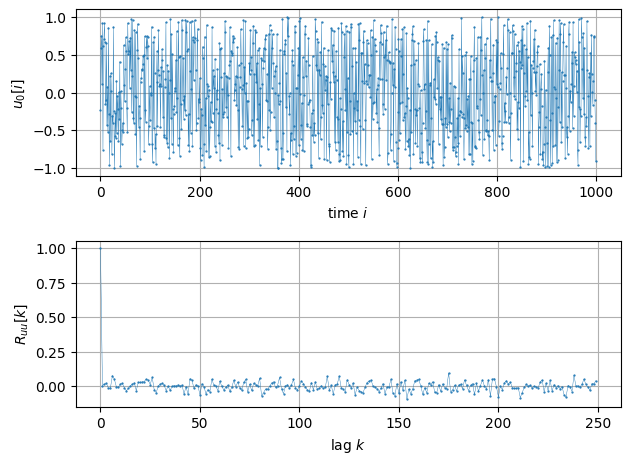

In [ ]:
u0 = np.random.uniform(low=-1, high=1, size=1000)
acf     = ACF(u0)

fig, ax = graph_paper(lab1=r'$u_0[i]$', lab2=r'$R_{uu}[k]$')
ax[0].plot(u0, '.-')
ax[1].plot(acf[:len(u)//4], '.-', label='ACF')      #全長の1/4

### ● ガウス白色過程 (Gaussian white process)

値の分布がガウス分布（＝正規分布）であるような白色過程を，**ガウス白色過程 (Gaussian white process)** といいます．
<br/>特に，平均0，分散1のガウス白色過程を，**標準ガウス白色過程 (standard Gaussian white process)** といいます．

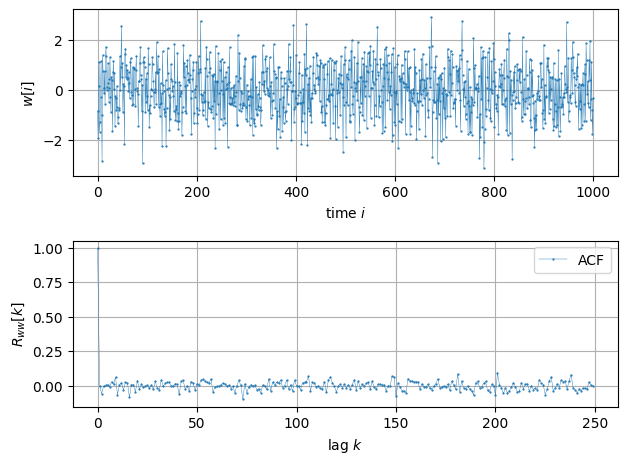

In [ ]:
x_w = np.random.normal(
    loc=0,    #平均を指定する(location の略？)
    scale=1,  #標準偏差を指定する(縮尺の意味？)
    size=1000
)
# loc=0, scale=1 はデフォルト値なので省略可能

acf_w = ACF(x_w)

fig, ax = graph_paper(lab1=r'$w[i]$', lab2=r'$R_{ww}[k]$')
ax[0].plot(x_w, '.-')
ax[1].plot(acf_w[:len(u)//4], '.-', label='ACF')      #全長の1/4
ax[1].legend()

## ■ マルコフ過程

続いて，２番目に無作為な確率過程として，**マルコフ過程 (Markov process)** を紹介しましょう．

マルコフ過程とは，現在の状態が，１時刻前の状態にだけ影響される確率過程のことです．これは，無相関過程の無作為性を，１段階弱めたものに相当します．

影響する過去を増やして，$h$ 時刻前から $1$ 時刻前までが現在に影響するものを，$h$ 階マルコフ過程といいます．

### ● 酔歩 (random walk)

最もシンプルなマルコフ過程に，**酔歩**があります．

酔歩とは，一歩の増分が白色過程で与えられる確率過程のことです．これを満足する標本路 $r[i]$ は，次の漸化式で生成できます．

$$
x[i] = x[i-1] + w[i]
,\quad x[0] =0
,\quad i=1,\cdots,n
$$

ただし，$w[i]$ は白色過程です．１時刻前の状態 $x[i-1]$ が，現在 $x[i]$ に影響を及ぼすので，確かにマルコフ過程となります．

特に，増分 $w[i]$ がガウス白色過程であるような酔歩を，**離散時間ブラウン運動 (discrete time Brownian motion)** といいます．

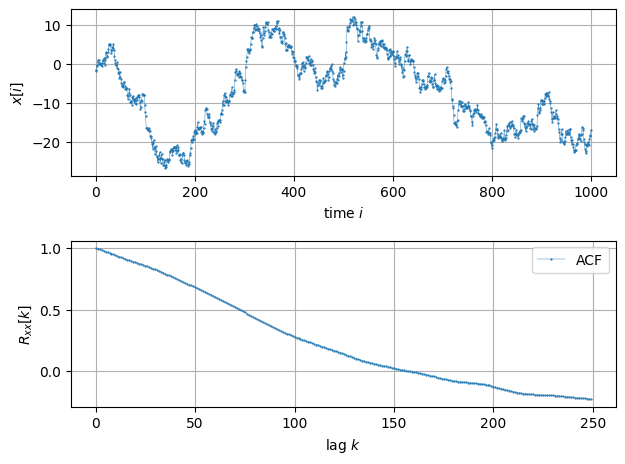

In [ ]:
np.random.seed(100)

def random_walk(size):
    """酔歩の生成"""
    w = np.random.normal(size=size)
    x, xi = [], 0
    for wi in w:
        xi = xi + wi
        x = x + [xi]    #x に現在値を追加
    return x

x_rw = random_walk(size=1000)
acf_rw = ACF(x_rw)

fig, ax = graph_paper(lab1=r'$x[i]$', lab2=r'$R_{xx}[k]$')
ax[0].plot(x_rw, '.-')
ax[1].plot(acf_rw[:len(x_rw)//4], '.-', label='ACF')      #全長の1/4
ax[1].legend()

１時刻前の影響を入れた結果，デルタ相関は消失しましたが，減衰はしています．
<br/> これは，演習４，５の極端な再帰性（一定の値や振幅）までは示さない，中程度のランダム性を表しています

### ● 自己回帰過程 (autoregressive process, AR process)

$h$ 次マルコフ過程の簡単な例として，**自己回帰過程**があります．

$$
x[i] = c_1 x[i-1] + \cdots + c_h x[i-h] + w[i]  
$$
$w[i]$ は白色過程です．$h$ を**次数 (order)** といいます．



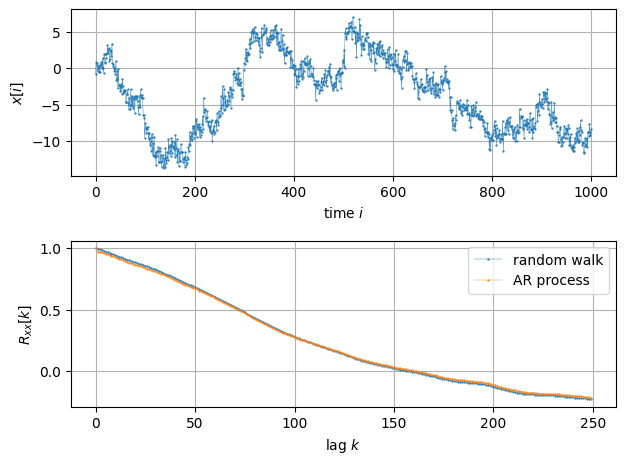

In [ ]:
np.random.seed(100) # 比較のため，白色過程のシードを揃えておきます．

def AR_process(h, size):
    """自己回帰過程の生成"""
    x, xi = [], 0

    #履歴項の設定
    h = 3 #マルコフ過程の階数．お試しに 3 とした．
    c = [1/h for i in range(h)] #係数はお試しに全て 1/h とした．

    #履歴を保存するリスト．最初は初期値だけ入れとく
    x_his = [xi]

    #白色過程
    w = np.random.normal(size=h + 1000) #履歴の長さだけ長くとる．

    for wi in w:
        x_sum = sum([c[j]*x_his[j] for j in range(len(x_his))])
        xi = x_sum + wi

        if len(x_his) < h:
            #履歴リストが一杯になるまでは，単に現在値を追加
            x_his = x_his + [xi]
        else:
            #履歴リストが一杯になったら，履歴の先頭を除外して，現在値を末尾に追加
            x_his = x_his[1:] + [xi]

        x.append(xi)

    return x[h:] #履歴が不完全な先頭 $h$ 個は除外

#次数 3 でお試し
x_ar = AR_process(h=3, size=1000)
acf_ar = ACF(x_ar)

fig, ax = graph_paper(lab1=r'$x[i]$', lab2=r'$R_{xx}[k]$')
ax[0].plot(x_ar, '.-')
ax[1].plot(acf_rw[:len(x_rw)//4], '.-', label='random walk')
ax[1].plot(acf_ar[:len(x_ar)//4], '.-', label='AR process')      #全長の1/4
ax[1].legend()

この自己回帰過程は，$h=3$ つ過去からの情報を受け継いでます．
<br/>酔歩に比べて，過去からの影響が長いので，もっと減衰が遅くてもよさそうですが，明確な違いは検出できませんでした．

### ● 偏自己相関関数 (partial autocorrelation function, PACF)

こんなときに便利な関数がありまして，**偏自己相関関数 (partial autocorrelation function, PACF)** といいます．
</br>偏自己相関関数を使うと，過去からの影響の長さを評価できます．

詳細は専門書に譲りますが，偏自己相関関数とは，観測データに最も良くフィットする自己回帰モデルの係数列を，最小二乗法で推定したものです．



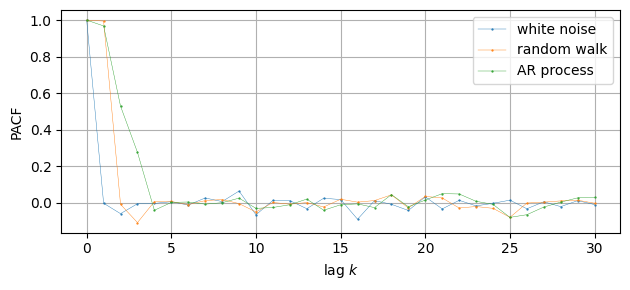

In [ ]:
import statsmodels.tsa.stattools as sts #より専門的なライブラリが必要

pacf_w = sts.pacf(x_w)
pacf_rw = sts.pacf(x_rw)
pacf_ar = sts.pacf(x_ar)

fig, ax = plt.subplots(1,1, figsize=(6.4, 3.0))
ax.plot(pacf_w[:len(x_w)//4], '.-', label='white noise')
ax.plot(pacf_rw[:len(x_rw)//4], '.-', label='random walk')
ax.plot(pacf_ar[:len(x_ar)//4], '.-', label='AR process')
ax.set_xlabel(r'lag $k$')
ax.set_ylabel(r'PACF')

ax.grid(); ax.legend(); fig.tight_layout()

結果の見方ですが，高さが $0$ より大きいラグ $k$ の分だけ，過去からの影響があります．
<br/>$0$ 付近のばらつきを無視すると，以下の評価結果を得ます．

- 白色過程は，ラグ $k=0$ だけが非ゼロ値．完全にランダム．
- 酔歩は，ラグ $k=0,1$ が非ゼロ値．1つ前からの影響がある．
- $h=3$ 次の自己回帰過程は，$k=0,1,2,3$ が非ゼロ値．3つ前からの影響がある．

標本路の生成方法と，よく一致した評価結果が得られています．